In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load multiclass dataset
df = pd.read_csv("multiclass_dataset.csv")

print(df.head())
print(df.shape)
print(df.iloc[:, -1].value_counts(dropna=False))

   kills  deaths  assists  gold_earned  gold_spent  \
0     11      11       11        12570       11800   
1      0       7        5         8306        8155   
2      1       8       16        12148       11625   
3      1       6       16         7114        6200   
4      3       5        1         5136        4725   

   total_damage_dealt_to_champions  total_damage_taken  vision_score  \
0                            27500               54133            47   
1                            20100               19203            12   
2                            22068               38546           104   
3                            10973               21697            48   
4                             8134               13062            23   

   wards_placed  champion_mastery_points  solo_tier_encoded  
0            21                1756910.0                  6  
1             7                 101684.0                  7  
2            40                 236514.0                

In [3]:
# Features and response
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Response variable:", df.columns[-1])
print("Original number of features:", X.shape[1])
print("Classes:")
print(y.value_counts())

# Cut number of features in half
n_components_half = X.shape[1] // 2
print("Number of PCA components:", n_components_half)

Response variable: solo_tier_encoded
Original number of features: 10
Classes:
solo_tier_encoded
6    1702
3    1118
5    1007
4     872
7     805
2     789
1     562
0     269
8     118
9      31
Name: count, dtype: int64
Number of PCA components: 5


In [4]:
# 90% training, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Validation features shape:", X_val.shape)

Training features shape: (6545, 10)
Validation features shape: (728, 10)


In [5]:
# Save reduced train/validation files after fitting PCA on training data only
scaler_for_save = StandardScaler()
X_train_scaled = scaler_for_save.fit_transform(X_train)
X_val_scaled = scaler_for_save.transform(X_val)

pca_for_save = PCA(n_components=n_components_half)
X_train_reduced = pca_for_save.fit_transform(X_train_scaled)
X_val_reduced = pca_for_save.transform(X_val_scaled)

train_reduced_df = pd.DataFrame(
    X_train_reduced,
    columns=[f"PC{i+1}" for i in range(n_components_half)]
)
train_reduced_df[df.columns[-1]] = y_train.reset_index(drop=True)

val_reduced_df = pd.DataFrame(
    X_val_reduced,
    columns=[f"PC{i+1}" for i in range(n_components_half)]
)
val_reduced_df[df.columns[-1]] = y_val.reset_index(drop=True)

train_reduced_df.to_csv("multiclass_pca_train.csv", index=False)
val_reduced_df.to_csv("multiclass_pca_validation.csv", index=False)

print(train_reduced_df.head())
print(val_reduced_df.head())

        PC1       PC2       PC3       PC4       PC5  solo_tier_encoded
0 -1.316761 -1.772884 -0.076421 -0.123078 -0.305075                  1
1  2.354553 -0.802311 -0.001730 -0.499827  0.865499                  5
2  0.407205 -1.398459  0.323131 -0.762216  0.150207                  6
3 -1.791900 -1.313294 -0.169945 -0.335778 -0.408649                  3
4  1.574660 -0.111322 -0.429587 -0.173630  1.397046                  3
        PC1       PC2       PC3       PC4       PC5  solo_tier_encoded
0 -2.121012  1.160211  0.145674 -0.775622 -0.620833                  3
1  2.989716  0.384778  0.445302 -0.721185 -1.067650                  7
2  0.418881  0.552802  0.484743 -1.089503  1.252209                  0
3  1.634402  0.100249  2.669849  0.672040  0.199611                  7
4 -1.881317 -0.327988 -0.126635 -0.543293  0.294326                  6


In [6]:
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter values
k_values = [3, 5, 7, 9, 11]
rf_values = [50, 100, 150, 200, 300]

In [7]:
# KNN cross-validation with PCA
knn_means = []
knn_stds = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components_half)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    knn_means.append(scores.mean())
    knn_stds.append(scores.std())
    print(f"KNN + PCA, k={k}: mean={scores.mean():.4f}, std={scores.std():.4f}")

KNN + PCA, k=3: mean=0.1444, std=0.0064
KNN + PCA, k=5: mean=0.1627, std=0.0081
KNN + PCA, k=7: mean=0.1757, std=0.0044
KNN + PCA, k=9: mean=0.1768, std=0.0070
KNN + PCA, k=11: mean=0.1856, std=0.0061


In [11]:
# Random Forest cross-validation with PCA
rf_means = []
rf_stds = []

for n in rf_values:
    rf_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components_half)),
        ("rf", RandomForestClassifier(n_estimators=n, random_state=42))
    ])
    
    scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    rf_means.append(scores.mean())
    rf_stds.append(scores.std())
    print(f"Random Forest + PCA, n_estimators={n}: mean={scores.mean():.4f}, std={scores.std():.4f}")

Random Forest + PCA, n_estimators=50: mean=0.1939, std=0.0084
Random Forest + PCA, n_estimators=100: mean=0.1947, std=0.0102
Random Forest + PCA, n_estimators=150: mean=0.1994, std=0.0124
Random Forest + PCA, n_estimators=200: mean=0.2009, std=0.0130
Random Forest + PCA, n_estimators=300: mean=0.2012, std=0.0133


In [12]:
# Save CV results into tables
knn_cv_results = pd.DataFrame({
    "k": k_values,
    "mean_cv_accuracy": knn_means,
    "std_cv_accuracy": knn_stds
})

rf_cv_results = pd.DataFrame({
    "n_estimators": rf_values,
    "mean_cv_accuracy": rf_means,
    "std_cv_accuracy": rf_stds
})

print("KNN + PCA CV Results")
print(knn_cv_results)

print("\nRandom Forest + PCA CV Results")
print(rf_cv_results)

KNN + PCA CV Results
    k  mean_cv_accuracy  std_cv_accuracy
0   3          0.144385         0.006355
1   5          0.162720         0.008128
2   7          0.175707         0.004402
3   9          0.176776         0.007045
4  11          0.185638         0.006131

Random Forest + PCA CV Results
   n_estimators  mean_cv_accuracy  std_cv_accuracy
0            50          0.193888         0.008360
1           100          0.194652         0.010231
2           150          0.199389         0.012413
3           200          0.200917         0.012965
4           300          0.201222         0.013255


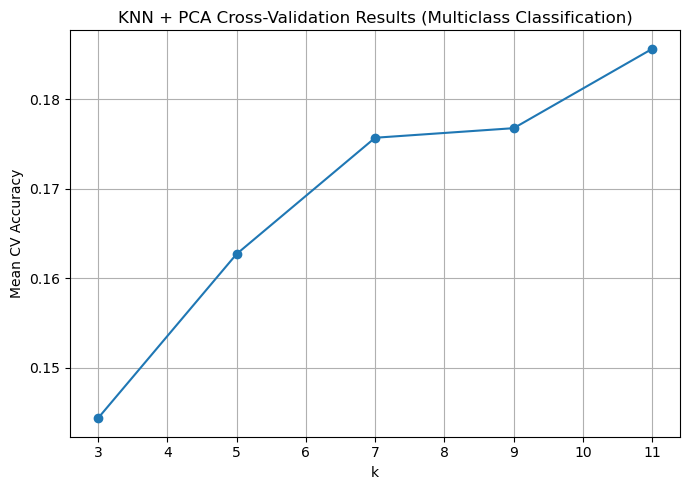

In [10]:
# Plot KNN CV results
plt.figure(figsize=(7, 5))
plt.plot(k_values, knn_means, marker="o")
plt.xlabel("k")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN + PCA Cross-Validation Results (Multiclass Classification)")
plt.grid(True)
plt.tight_layout()
plt.savefig("knn_multiclass_pca_cv.png", dpi=300)
plt.show()

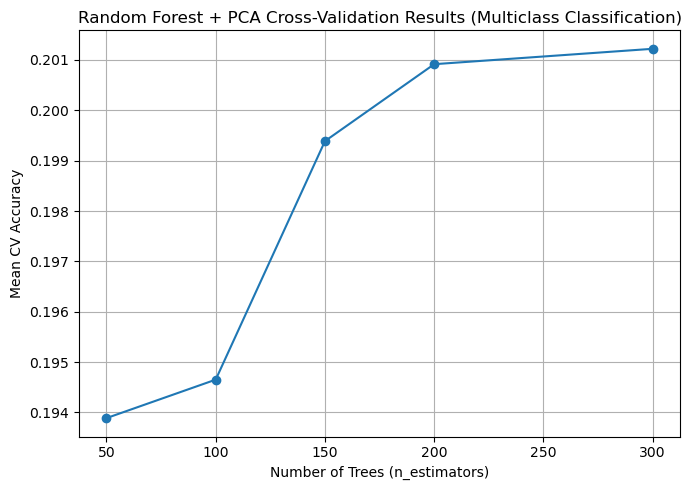

In [13]:
# Plot Random Forest CV results
plt.figure(figsize=(7, 5))
plt.plot(rf_values, rf_means, marker="o")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest + PCA Cross-Validation Results (Multiclass Classification)")
plt.grid(True)
plt.tight_layout()
plt.savefig("rf_multiclass_pca_cv.png", dpi=300)
plt.show()

In [14]:
# Choose best hyperparameters
best_k = k_values[int(np.argmax(knn_means))]
best_rf = rf_values[int(np.argmax(rf_means))]

best_knn_cv = max(knn_means)
best_rf_cv = max(rf_means)

print("Best KNN k:", best_k, "| Mean CV Accuracy:", best_knn_cv)
print("Best Random Forest n_estimators:", best_rf, "| Mean CV Accuracy:", best_rf_cv)

Best KNN k: 11 | Mean CV Accuracy: 0.18563789152024446
Best Random Forest n_estimators: 300 | Mean CV Accuracy: 0.20122230710466002


In [15]:
# Train final KNN + PCA model and measure training time
final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_half)),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

start_train_knn = time.perf_counter()
final_knn.fit(X_train, y_train)
end_train_knn = time.perf_counter()

knn_train_time = end_train_knn - start_train_knn

knn_train_pred = final_knn.predict(X_train)
knn_train_acc = accuracy_score(y_train, knn_train_pred)

print("Final KNN + PCA")
print("Training accuracy:", knn_train_acc)
print("Training time (seconds):", knn_train_time)

Final KNN + PCA
Training accuracy: 0.34255156608097787
Training time (seconds): 0.02098899999691639


In [16]:
# Validate final KNN + PCA model and measure testing time
start_test_knn = time.perf_counter()
knn_val_pred = final_knn.predict(X_val)
end_test_knn = time.perf_counter()

knn_test_time = end_test_knn - start_test_knn
knn_val_acc = accuracy_score(y_val, knn_val_pred)

print("Final KNN + PCA")
print("Validation accuracy:", knn_val_acc)
print("Testing time (seconds):", knn_test_time)

Final KNN + PCA
Validation accuracy: 0.19093406593406592
Testing time (seconds): 0.020816100004594773


In [17]:
# Train final Random Forest + PCA model and measure training time
final_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_half)),
    ("rf", RandomForestClassifier(n_estimators=best_rf, random_state=42))
])

start_train_rf = time.perf_counter()
final_rf.fit(X_train, y_train)
end_train_rf = time.perf_counter()

rf_train_time = end_train_rf - start_train_rf

rf_train_pred = final_rf.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

print("Final Random Forest + PCA")
print("Training accuracy:", rf_train_acc)
print("Training time (seconds):", rf_train_time)

Final Random Forest + PCA
Training accuracy: 1.0
Training time (seconds): 6.503057900001295


In [18]:
# Validate final Random Forest + PCA model and measure testing time
start_test_rf = time.perf_counter()
rf_val_pred = final_rf.predict(X_val)
end_test_rf = time.perf_counter()

rf_test_time = end_test_rf - start_test_rf
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("Final Random Forest + PCA")
print("Validation accuracy:", rf_val_acc)
print("Testing time (seconds):", rf_test_time)

Final Random Forest + PCA
Validation accuracy: 0.23351648351648352
Testing time (seconds): 0.14705079999839654


In [19]:
# Final summary table
summary = pd.DataFrame({
    "Model": ["KNN + PCA", "Random Forest + PCA"],
    "Best Hyperparameter": [f"k={best_k}", f"n_estimators={best_rf}"],
    "Mean CV Accuracy": [best_knn_cv, best_rf_cv],
    "Training Accuracy": [knn_train_acc, rf_train_acc],
    "Validation Accuracy": [knn_val_acc, rf_val_acc],
    "Training Time (s)": [knn_train_time, rf_train_time],
    "Testing Time (s)": [knn_test_time, rf_test_time]
})

print(summary)
summary.to_csv("multiclass_problem2_pca_summary.csv", index=False)

                 Model Best Hyperparameter  Mean CV Accuracy  \
0            KNN + PCA                k=11          0.185638   
1  Random Forest + PCA    n_estimators=300          0.201222   

   Training Accuracy  Validation Accuracy  Training Time (s)  Testing Time (s)  
0           0.342552             0.190934           0.020989          0.020816  
1           1.000000             0.233516           6.503058          0.147051  
